In [2]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ── 1. Load Data ───────────────────────────────────────────────────────────────
df = pd.read_csv("./data/dataset_phishing.csv")

print("=" * 60)
print("STEP 1: INITIAL DATASET OVERVIEW")
print("=" * 60)
print(f"  Shape          : {df.shape}")
print(f"  Missing values : {df.isnull().sum().sum()}")
print(f"  Duplicate rows : {df.duplicated().sum()}")
print(f"  Feature types  :\n{df.dtypes.value_counts().to_string()}")

# ── 2. Remove Duplicates ───────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2: REMOVING DUPLICATES")
print("=" * 60)
before = len(df)
df.drop_duplicates(inplace=True)
removed = before - len(df)
print(f"  Rows before : {before}")
print(f"  Duplicates  : {removed}")
print(f"  Rows after  : {len(df)}")

# ── 3. Handle Missing Values ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3: MISSING VALUE HANDLING")
print("=" * 60)
missing_per_col = df.isnull().sum()
print(f"  Columns with missing values: {(missing_per_col > 0).sum()}")
print(f"  Total missing cells        : {missing_per_col.sum()}")
print("  → Dataset is complete. No imputation required.")

# ── 4. Drop Zero-Variance Features ────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4: REMOVING ZERO-VARIANCE FEATURES")
print("=" * 60)
zero_var_cols = ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection',
                 'ratio_intErrors', 'submit_email', 'sfh']
df.drop(columns=zero_var_cols, inplace=True)
print(f"  Dropped {len(zero_var_cols)} constant features: {zero_var_cols}")
print(f"  Shape after drop: {df.shape}")

# ── 5. Drop Non-Predictive Raw String Column ───────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5: DROPPING RAW URL COLUMN")
print("=" * 60)
df.drop(columns=['url'], inplace=True)
print("  Dropped 'url' (raw string, not a structured feature)")
print(f"  Shape after drop: {df.shape}")

STEP 1: INITIAL DATASET OVERVIEW
  Shape          : (11430, 89)
  Missing values : 0
  Duplicate rows : 0
  Feature types  :
int64      74
float64    13
object      2

STEP 2: REMOVING DUPLICATES
  Rows before : 11430
  Duplicates  : 0
  Rows after  : 11430

STEP 3: MISSING VALUE HANDLING
  Columns with missing values: 0
  Total missing cells        : 0
  → Dataset is complete. No imputation required.

STEP 4: REMOVING ZERO-VARIANCE FEATURES
  Dropped 6 constant features: ['nb_or', 'ratio_nullHyperlinks', 'ratio_intRedirection', 'ratio_intErrors', 'submit_email', 'sfh']
  Shape after drop: (11430, 83)

STEP 5: DROPPING RAW URL COLUMN
  Dropped 'url' (raw string, not a structured feature)
  Shape after drop: (11430, 82)


In [3]:
# ── 6. Handle Anomalous Negative Values ───────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 6: FIXING NEGATIVE VALUES (SENTINEL CODES)")
print("=" * 60)
neg_domain_age = (df['domain_age'] < 0).sum()
neg_reg_len    = (df['domain_registration_length'] < 0).sum()
print(f"  Negative 'domain_age'                : {neg_domain_age} rows → clipped to 0")
print(f"  Negative 'domain_registration_length': {neg_reg_len} rows → clipped to 0")
df['domain_age'] = df['domain_age'].clip(lower=0)
df['domain_registration_length'] = df['domain_registration_length'].clip(lower=0)

# ── 7. Feature Encoding — Target Variable ─────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 7: FEATURE ENCODING")
print("=" * 60)
le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"  Target 'status' label encoded: {mapping}")
print("  All other features are already numerical (int/float).")
print("  Binary features (0/1): no additional encoding needed.")

# ── 8. Identify Feature Types ─────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 8: FEATURE TYPE IDENTIFICATION")
print("=" * 60)
TARGET = 'status'
all_features = [c for c in df.columns if c != TARGET]
binary_cols = [c for c in all_features if set(df[c].unique()).issubset({0, 1})]
cont_cols   = [c for c in all_features if c not in binary_cols]
print(f"  Binary (0/1) features  : {len(binary_cols)}")
print(f"  Continuous features    : {len(cont_cols)}")
print(f"  Total features         : {len(all_features)}")

# ── 9. Log1p Transformation for High-Skew Features ────────────────────────────
print("\n" + "=" * 60)
print("STEP 9: LOG1P TRANSFORMATION (SKEWNESS REDUCTION)")
print("=" * 60)
skewness_before = df[cont_cols].skew()
high_skew_cols  = skewness_before[skewness_before.abs() > 1].index.tolist()
df[high_skew_cols] = np.log1p(df[high_skew_cols])
skewness_after  = df[cont_cols].skew()
print(f"  Continuous features with |skew| > 1 : {len(high_skew_cols)}")
print(f"  Features transformed                : {len(high_skew_cols)}")
print(f"\n  {'Feature':<35} {'Skew Before':>13} {'Skew After':>12}")
print("  " + "-" * 62)
for col in sorted(high_skew_cols, key=lambda c: abs(skewness_before[c]), reverse=True)[:10]:
    print(f"  {col:<35} {skewness_before[col]:>13.3f} {skewness_after[col]:>12.3f}")
print(f"  ... ({len(high_skew_cols)} total transformed)")

# ── 10. Robust Scaling of Continuous Features ──────────────────────────────────
print("\n" + "=" * 60)
print("STEP 10: ROBUST SCALING (CONTINUOUS FEATURES)")
print("=" * 60)
scaler = RobustScaler()
df[cont_cols] = scaler.fit_transform(df[cont_cols])
print(f"  RobustScaler applied to {len(cont_cols)} continuous features.")
print("  Formula: (x - median) / IQR  — robust to outliers.")
print(f"\n  Post-scaling stats (sample of 5 features):")
print(df[cont_cols[:5]].describe().round(3).to_string())


STEP 6: FIXING NEGATIVE VALUES (SENTINEL CODES)
  Negative 'domain_age'                : 1837 rows → clipped to 0
  Negative 'domain_registration_length': 46 rows → clipped to 0

STEP 7: FEATURE ENCODING
  Target 'status' label encoded: {'legitimate': np.int64(0), 'phishing': np.int64(1)}
  All other features are already numerical (int/float).
  Binary features (0/1): no additional encoding needed.

STEP 8: FEATURE TYPE IDENTIFICATION
  Binary (0/1) features  : 31
  Continuous features    : 50
  Total features         : 81

STEP 9: LOG1P TRANSFORMATION (SKEWNESS REDUCTION)
  Continuous features with |skew| > 1 : 42
  Features transformed                : 42

  Feature                               Skew Before   Skew After
  --------------------------------------------------------------
  nb_dollar                                  55.657       39.871
  nb_percent                                 35.424        8.062
  nb_comma                                   31.695       25.990
  nb_sp

In [4]:
# ── 11. Train / Test Split ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 11: TRAIN / TEST SPLIT (80 / 20, STRATIFIED)")
print("=" * 60)
X = df.drop(columns=[TARGET])
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"  Total samples  : {len(df)}")
print(f"  Train samples  : {len(X_train)}  ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Test  samples  : {len(X_test)}   ({len(X_test)/len(df)*100:.1f}%)")
print(f"  Feature count  : {X_train.shape[1]}")
print(f"\n  Train class distribution : {y_train.value_counts().to_dict()}")
print(f"  Test  class distribution : {y_test.value_counts().to_dict()}")


STEP 11: TRAIN / TEST SPLIT (80 / 20, STRATIFIED)
  Total samples  : 11430
  Train samples  : 9144  (80.0%)
  Test  samples  : 2286   (20.0%)
  Feature count  : 81

  Train class distribution : {0: 4572, 1: 4572}
  Test  class distribution : {1: 1143, 0: 1143}


In [7]:
# ── 12. Save Preprocessed Datasets ────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 12: SAVING OUTPUT FILES")
print("=" * 60)
train_df = pd.concat([X_train, y_train], axis=1)
test_df  = pd.concat([X_test,  y_test],  axis=1)
train_df.to_csv("./Week3/train_preprocessed.csv", index=False)
test_df.to_csv("./Week3/test_preprocessed.csv",   index=False)
df.to_csv("./Week3/full_preprocessed.csv",        index=False)
print("  Saved: train_preprocessed.csv")
print("  Saved: test_preprocessed.csv")
print("  Saved: full_preprocessed.csv")


STEP 12: SAVING OUTPUT FILES
  Saved: train_preprocessed.csv
  Saved: test_preprocessed.csv
  Saved: full_preprocessed.csv



Saved: fig_w3_skew_scale.png


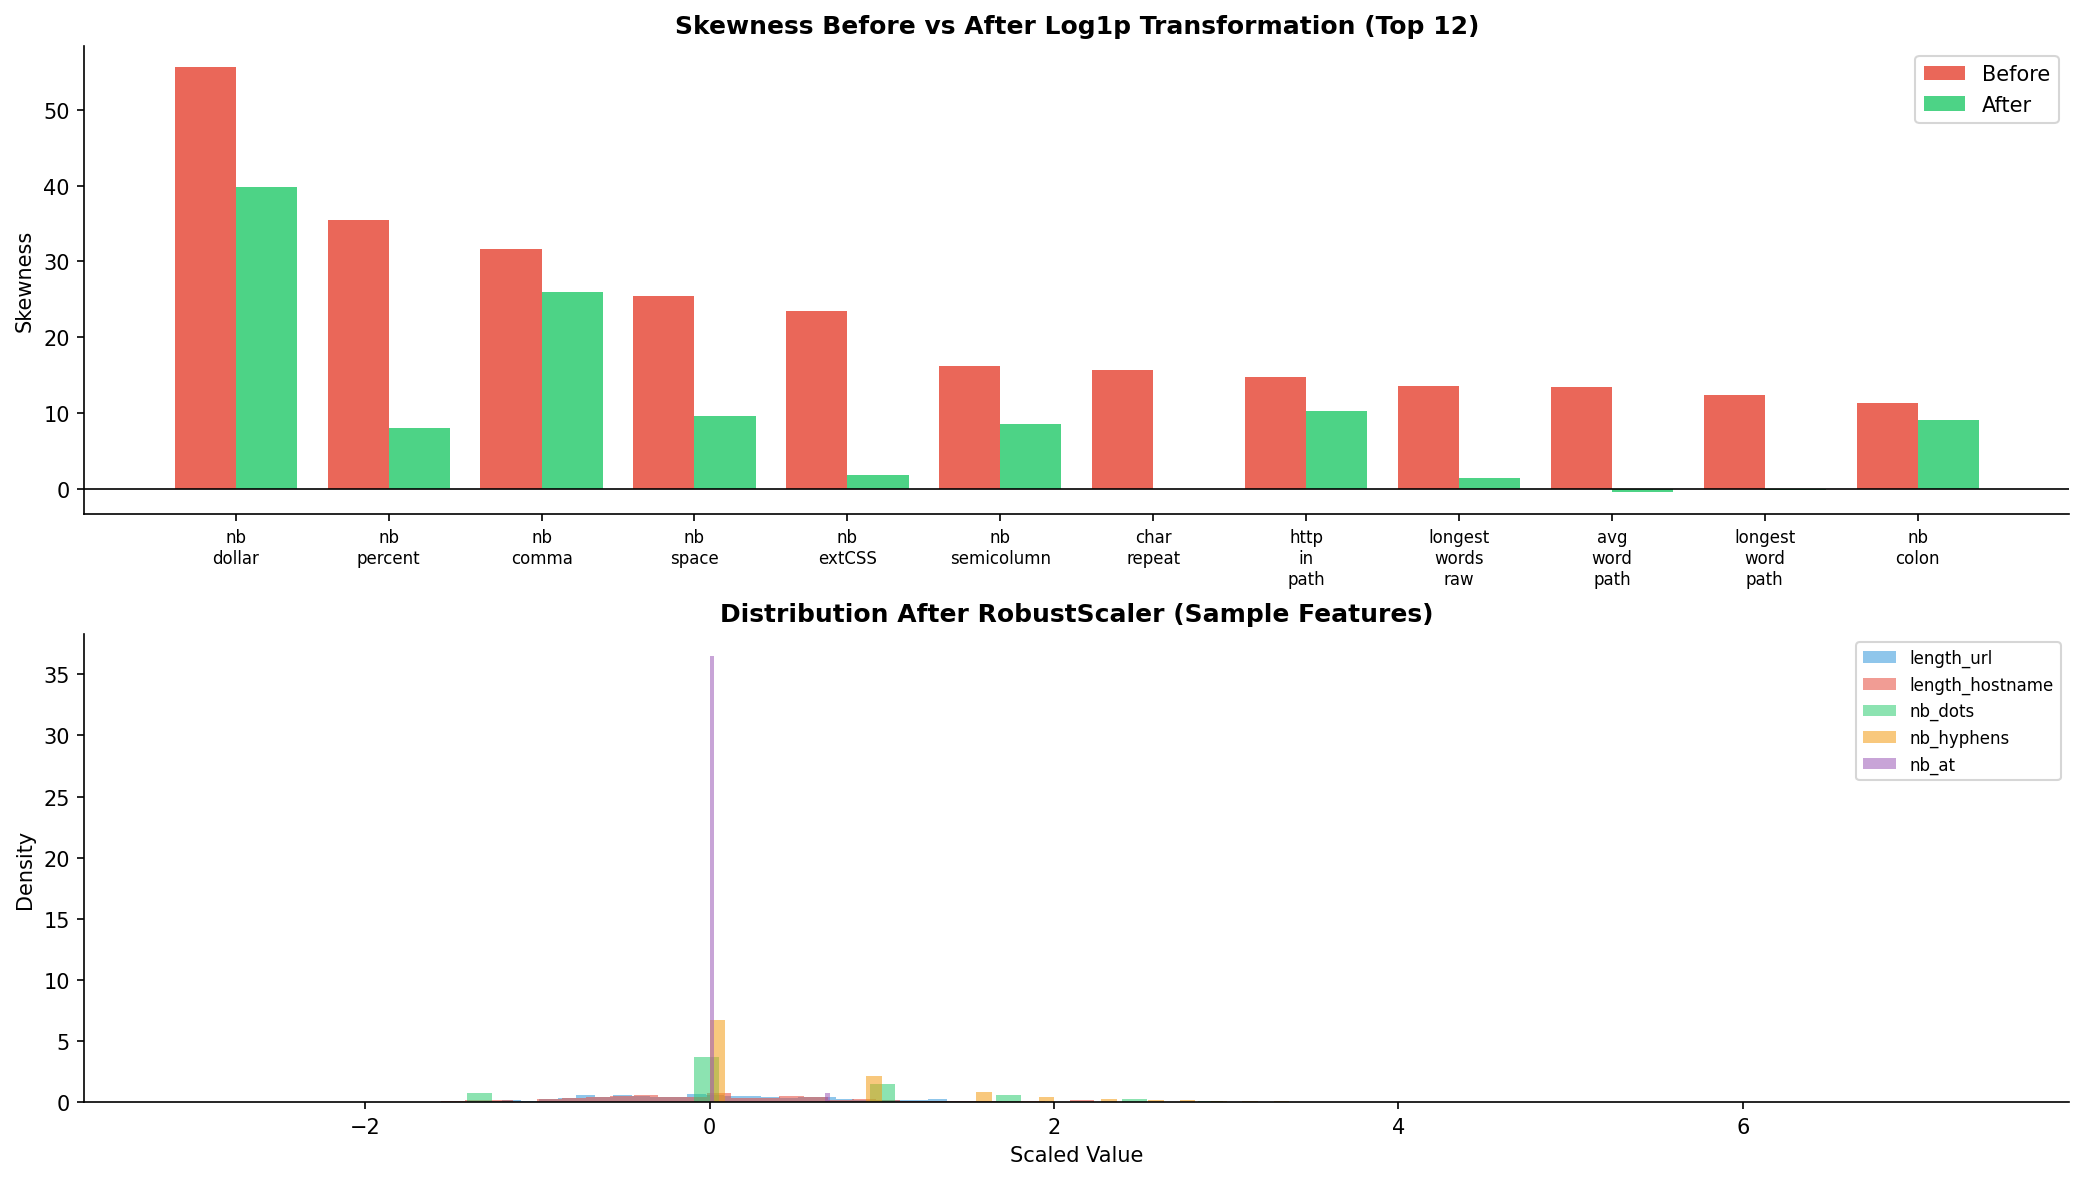

Saved: fig_w3_split_balance.png


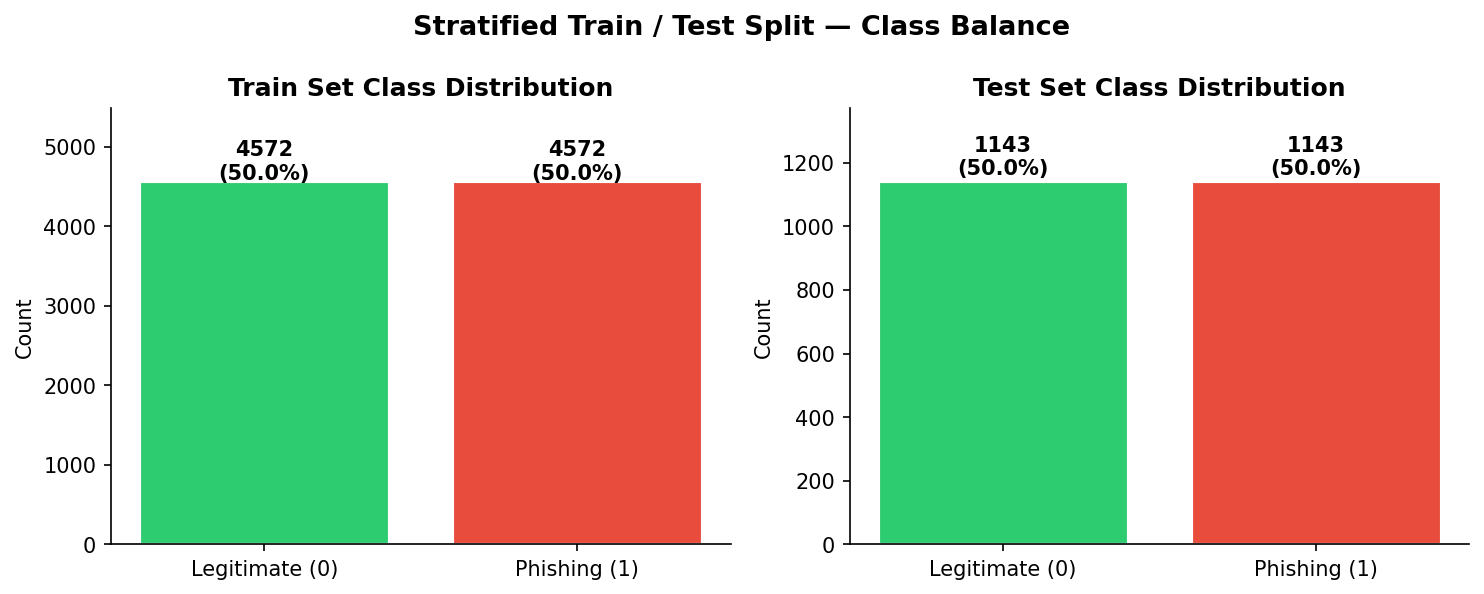

Saved: fig_w3_heatmap.png


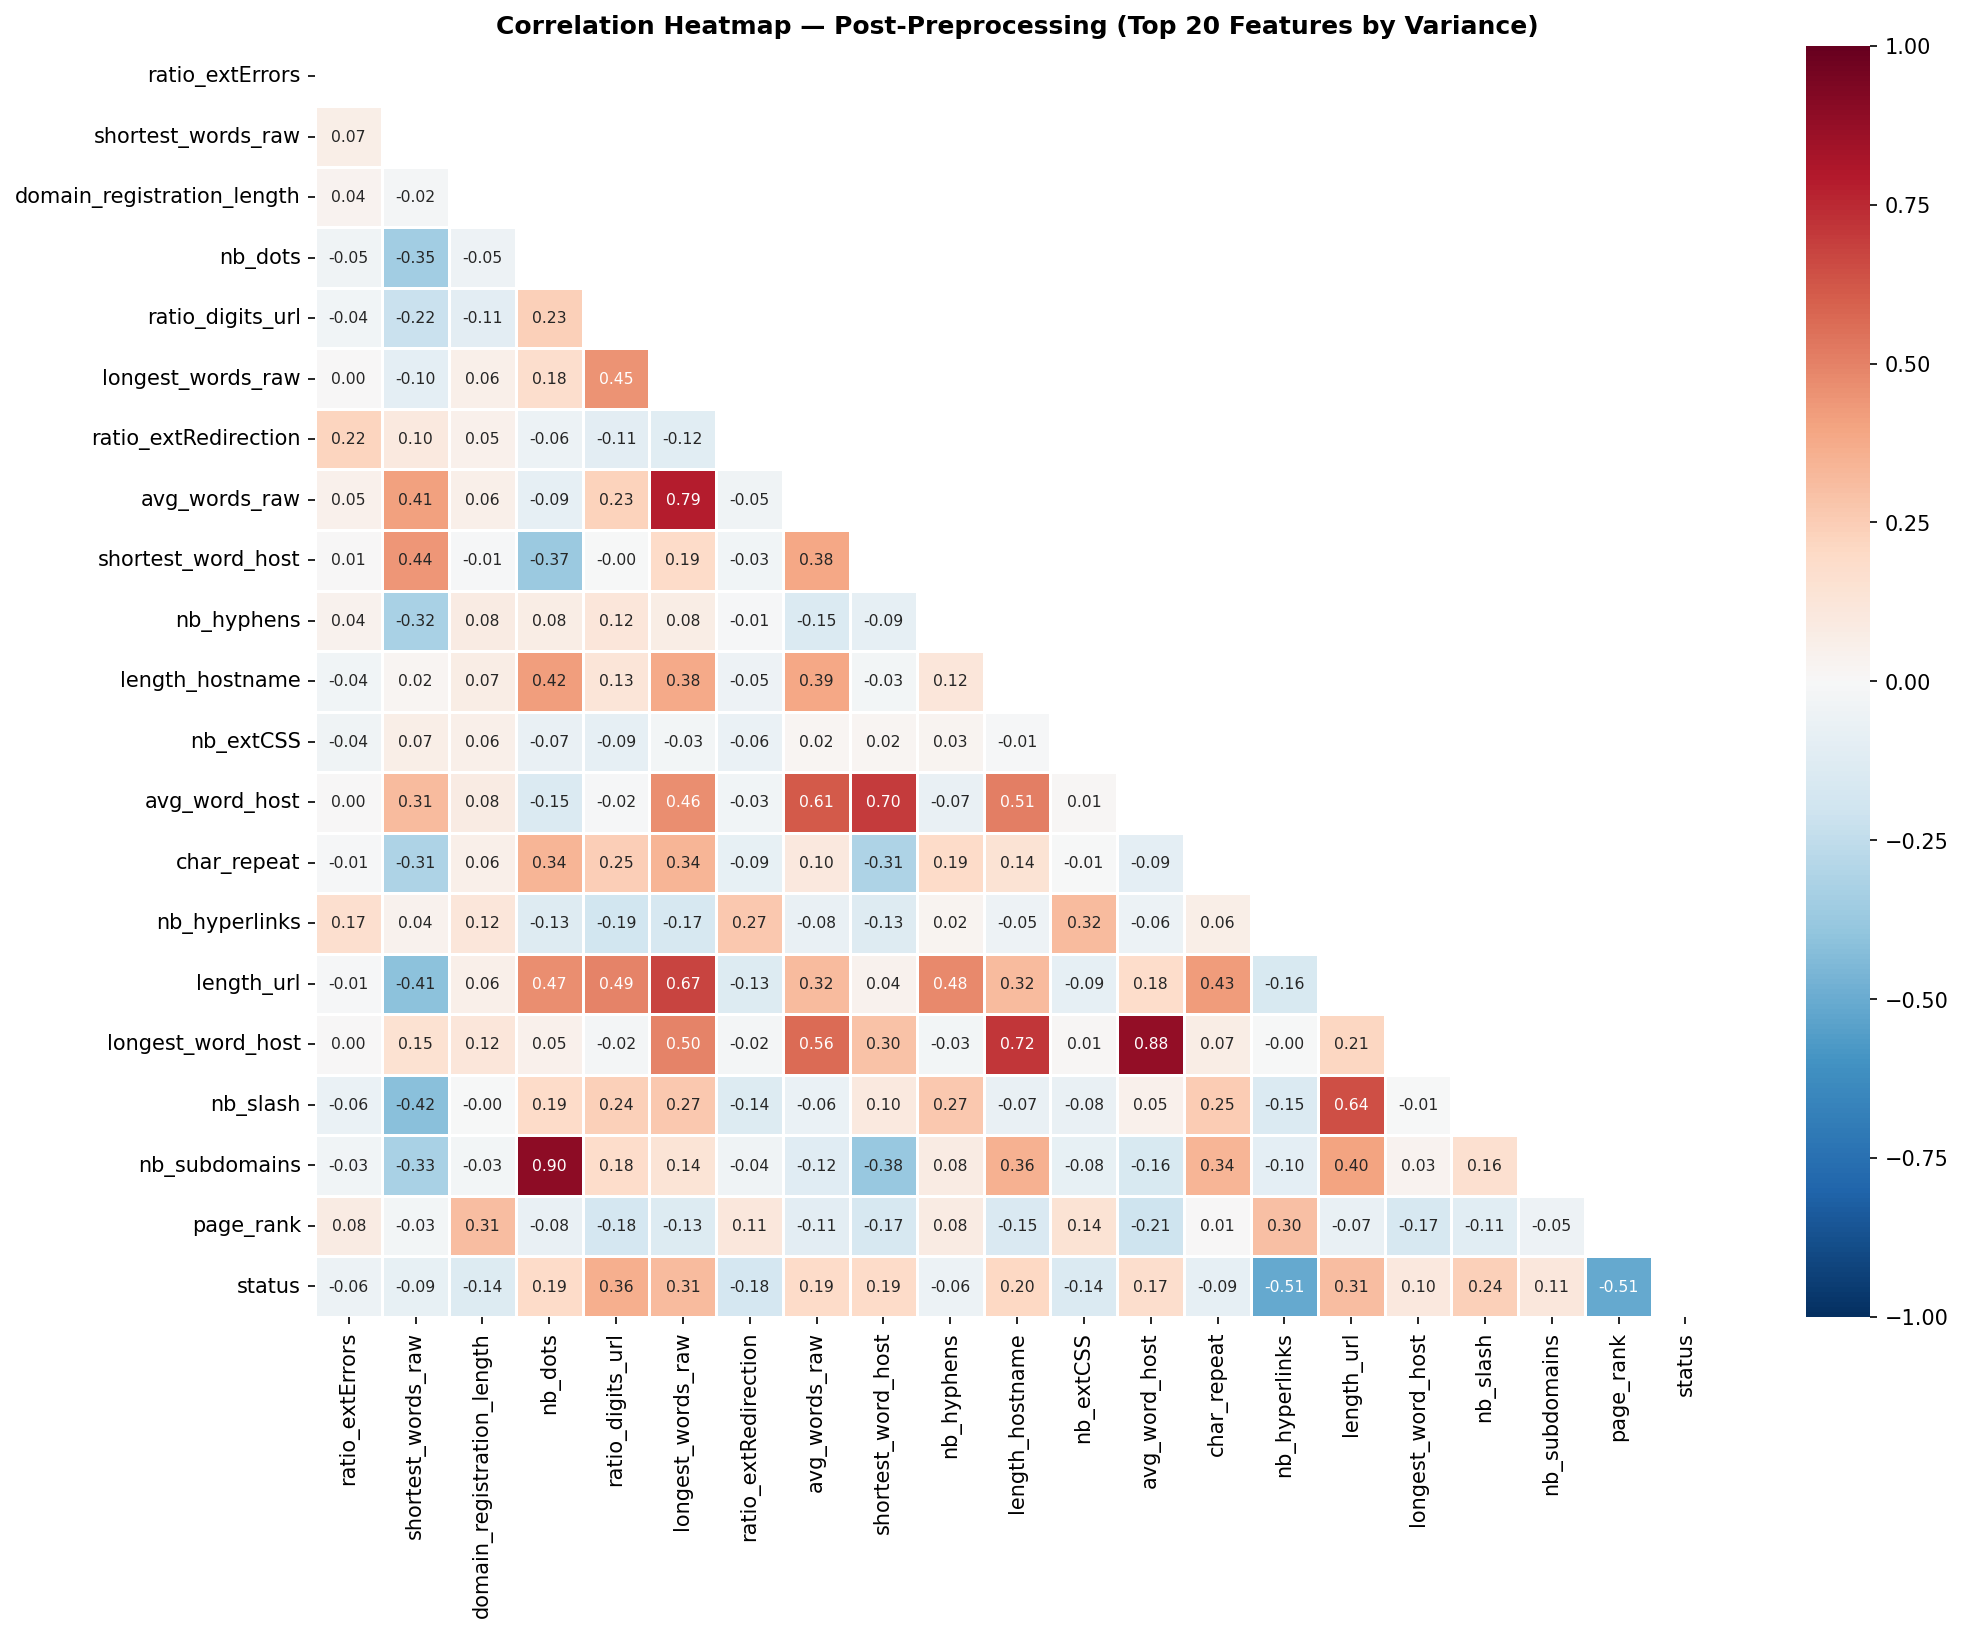

Saved: fig_w3_variance.png


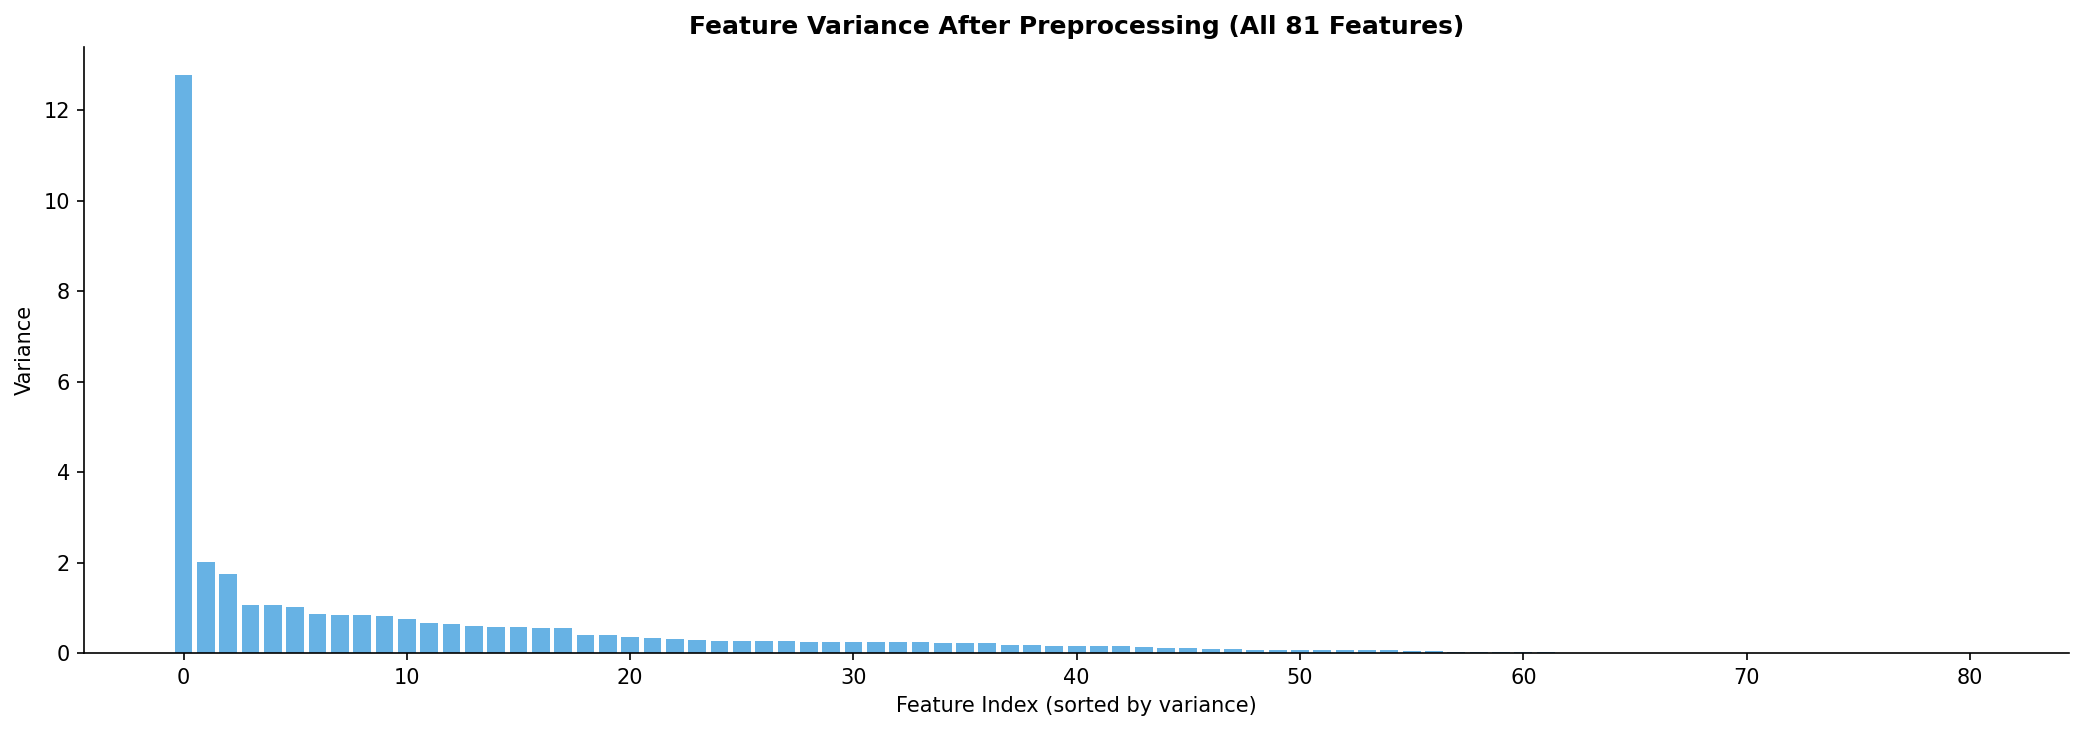


PREPROCESSING COMPLETE
  Final feature count  : 81
  Training set shape   : (9144, 81)
  Test set shape       : (2286, 81)
  Outputs: train_preprocessed.csv, test_preprocessed.csv,
           full_preprocessed.csv, fig_w3_*.png


In [11]:
# ── 13. Visualizations ─────────────────────────────────────────────────────────
import os
from IPython.display import Image, display
# Figure 1 — Skewness before vs after for top features
top_skew_cols = sorted(high_skew_cols,
                       key=lambda c: abs(skewness_before[c]), reverse=True)[:12]
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
x = np.arange(len(top_skew_cols))
w = 0.4
axes[0].bar(x - w/2, skewness_before[top_skew_cols], w,
            label='Before', color='#e74c3c', alpha=0.85)
axes[0].bar(x + w/2, skewness_after[top_skew_cols],  w,
            label='After',  color='#2ecc71', alpha=0.85)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([c.replace('_', '\n') for c in top_skew_cols], fontsize=8)
axes[0].set_ylabel('Skewness')
axes[0].set_title('Skewness Before vs After Log1p Transformation (Top 12)', fontweight='bold')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Figure 1b — Scaled distribution for 5 sample continuous features
sample_cont = cont_cols[:5]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
for i, col in enumerate(sample_cont):
    axes[1].hist(df[col], bins=60, alpha=0.55, label=col, color=colors[i], density=True)
axes[1].set_title('Distribution After RobustScaler (Sample Features)', fontweight='bold')
axes[1].set_xlabel('Scaled Value')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('./Week3/fig_w3_skew_scale.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nSaved: fig_w3_skew_scale.png")
display(Image(filename='./Week3/fig_w3_skew_scale.png'))


# Figure 2 — Train/Test class balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split_name, y_split) in zip(axes, [('Train', y_train), ('Test', y_test)]):
    counts = y_split.value_counts().sort_index()
    bars = ax.bar(['Legitimate (0)', 'Phishing (1)'], counts.values,
                  color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 20,
                f'{val}\n({val/len(y_split)*100:.1f}%)',
                ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'{split_name} Set Class Distribution', fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts.values) * 1.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.suptitle('Stratified Train / Test Split — Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./Week3/fig_w3_split_balance.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: fig_w3_split_balance.png")
display(Image(filename='./Week3/fig_w3_split_balance.png'))

# Figure 3 — Correlation heatmap (post-preprocessing, top 20 features by variance)
top20 = df[all_features].var().nlargest(20).index.tolist()
corr = df[top20 + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={"size": 7.5}, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Post-Preprocessing (Top 20 Features by Variance)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./Week3/fig_w3_heatmap.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: fig_w3_heatmap.png")
display(Image(filename='./Week3/fig_w3_heatmap.png'))

# Figure 4 — Feature variance after scaling (sorted)
variances = df[all_features].var().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(variances)), variances.values, color='#3498db', alpha=0.75)
ax.set_title('Feature Variance After Preprocessing (All 81 Features)', fontweight='bold')
ax.set_xlabel('Feature Index (sorted by variance)')
ax.set_ylabel('Variance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('./Week3/fig_w3_variance.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: fig_w3_variance.png")
display(Image(filename='./Week3/fig_w3_variance.png'))

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)
print(f"  Final feature count  : {X.shape[1]}")
print(f"  Training set shape   : {X_train.shape}")
print(f"  Test set shape       : {X_test.shape}")
print("  Outputs: train_preprocessed.csv, test_preprocessed.csv,")
print("           full_preprocessed.csv, fig_w3_*.png")